# Temporal Alignment Testing for Plant Sequences

This notebook tests different methods for temporally aligning plant sequences from TrackPlant3D dataset.

We'll test:
1. **Translation-only ICP**: Only translation, no rotation (from get_dense_gt_TrackPlant3D.py)
2. **Full ICP**: Translation + rotation (from icp_alignment.py)
3. **Stem-based alignment**: Using only stem points (label 0) for alignment
4. **PCA alignment**: The existing PCA method in the dataset loader
5. **Multi-stage stem-based**: first stem-based alignment, then rotation ICP refinement and base of plant to origin centering 


In [2]:
import colorsys
from pathlib import Path

import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

from plant_shape_analysis.dataloaders.trackplant3D import PlantSequencesDataset
from plant_shape_analysis.vis.plot_functions import visualize_plant_sequence
from plant_shape_analysis.vis.plot_functions import COLOR_MAP

%load_ext autoreload
%autoreload 2

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Load dataset

In [ ]:
# Load dataset without alignment
dataset_path = Path("../data/TrackPlant3D/versions")

# Load without any alignment first
plant_dataset = PlantSequencesDataset(
    dataset_path,
    version="v1",
    use_ply=True,
    alignment_method=None,
    auto_download=False
)

print(f"Loaded {len(plant_dataset)} plant sequences")
print(f"Sequence names: {plant_dataset.get_sequence_names()}")

## Select a Test Sequence

In [ ]:
# Select a sequence to test
sequence_name = "maize_control_plant1"

# Get sequence data
timeseries = plant_dataset.get_timeseries_by_sequence_name(sequence_name)
timepoints = timeseries['timepoints']

print(f"Sequence: {sequence_name}")
print(f"Number of timepoints: {len(timepoints)}")
print(f"Days: {[tp['day'] for tp in timepoints]}")

# Old aligment tests

## Alignment Methods

### 1. Translation-Only ICP

In [ ]:
def translation_only_icp(source_points, target_points, max_iterations=200, tolerance=1e-6):
    """
    Translation-only ICP alignment (from get_dense_gt_TrackPlant3D.py)
    
    Args:
        source_points: Points to align (N, 3)
        target_points: Reference points (M, 3)
    
    Returns:
        translation: Optimal translation vector (3,)
        final_error: Final mean squared error
        iterations: Number of iterations used
    """
    source = np.array(source_points, dtype=np.float64)
    target = np.array(target_points, dtype=np.float64)
    
    # Initialize translation to zero
    translation = np.zeros(3)
    prev_error = float('inf')
    
    # Build KD-tree for fast nearest neighbor search
    kdtree = cKDTree(target)
    
    for iteration in range(max_iterations):
        # Apply current translation
        transformed_source = source + translation
        
        # Find nearest neighbors
        distances, indices = kdtree.query(transformed_source, k=1)
        closest_target_points = target[indices]
        
        # Calculate current mean squared error
        current_error = np.mean(distances**2)
        
        # Check convergence
        if abs(prev_error - current_error) < tolerance:
            break
        
        # Compute optimal translation using centroids
        source_centroid = np.mean(transformed_source, axis=0)
        target_centroid = np.mean(closest_target_points, axis=0)
        
        # Update translation
        translation_update = target_centroid - source_centroid
        translation += translation_update
        
        prev_error = current_error
        
        # Early stopping
        if np.linalg.norm(translation_update) < tolerance:
            break
    
    return translation, current_error, iteration + 1

### 2. Stem-Based Alignment

Align using only stem points (label 0)

In [ ]:
def stem_based_alignment(source_points, source_labels, target_points, target_labels, 
                        use_rotation=False, max_iterations=200):
    """
    Align plant point clouds using only stem points (label 0)
    
    Args:
        source_points: Points to align (N, 3)
        source_labels: Labels for source points (N,)
        target_points: Reference points (M, 3)
        target_labels: Labels for target points (M,)
        use_rotation: Whether to include rotation (False = translation only)
    
    Returns:
        translation: Translation vector (3,)
        rotation: Rotation matrix (3, 3) if use_rotation=True, else identity
        error: Final alignment error
    """
    # Extract stem points (label 0)
    source_stem = source_points[source_labels == 0]
    target_stem = target_points[target_labels == 0]
    
    print(f"Stem points - Source: {len(source_stem)}, Target: {len(target_stem)}")
    
    if len(source_stem) == 0 or len(target_stem) == 0:
        print("Warning: No stem points found in one or both point clouds")
        return np.zeros(3), np.eye(3), float('inf')
    
    if use_rotation:
        # Use full ICP with rotation on stem points
        from plant_shape_analysis.alignment.icp_alignment import align_plant_pair_icp
        aligned_stem, rotation, translation = align_plant_pair_icp(
            source_stem, target_stem,
            max_iterations=max_iterations,
            convergence_threshold=0.01
        )
        
        # Compute error
        kdtree = cKDTree(target_stem)
        distances, _ = kdtree.query(aligned_stem, k=1)
        error = np.mean(distances**2)
    else:
        # Use translation-only ICP on stem points
        translation, error, iters = translation_only_icp(
            source_stem, target_stem, 
            max_iterations=max_iterations
        )
        rotation = np.eye(3)
        print(f"Translation-only ICP converged in {iters} iterations")
    
    return translation, rotation, error

## Test All Methods on Sequence

We'll align all timepoints to the first timepoint (reference) and compare methods.

In [ ]:
# Choose reference timepoint (usually the first one)
reference_idx = 0
ref_tp = timepoints[reference_idx]
ref_points = ref_tp['points']
ref_labels = ref_tp['labels']
ref_center = np.mean(ref_points, axis=0)

print(f"Reference timepoint: Day {ref_tp['day']}")
print(f"Reference points: {len(ref_points)}")
print(f"Reference center: {ref_center}")

In [ ]:
# Test alignment methods on each timepoint
results = {
    'translation_only_full': [],
    'stem_translation_only': [],
    'stem_with_rotation': [],
}

for i, tp in enumerate(timepoints):
    if i == reference_idx:
        # Reference stays the same
        for method in results.keys():
            results[method].append({
                'day': tp['day'],
                'translation': np.zeros(3),
                'rotation': np.eye(3),
                'error': 0.0,
                'aligned_points': ref_points,
                'aligned_labels': ref_labels,  # FIXED: Added this line
                'is_reference': True
            })
        continue
    
    points = tp['points']
    labels = tp['labels']
    
    print(f"\nAligning Day {tp['day']} to reference (Day {ref_tp['day']})")
    print(f"Points: {len(points)}")
    
    # Method 1: Translation-only ICP (full plant)
    print("\n1. Translation-only ICP (full plant)")
    trans1, error1, iters1 = translation_only_icp(points, ref_points)
    aligned1 = points + trans1
    print(f"   Translation: {trans1}")
    print(f"   Error: {error1:.6f}, Iterations: {iters1}")
    results['translation_only_full'].append({
        'day': tp['day'],
        'translation': trans1,
        'rotation': np.eye(3),
        'error': error1,
        'aligned_points': aligned1,
        'aligned_labels': labels,
        'is_reference': False
    })
    
    # Method 2: Stem-based translation-only
    print("\n2. Stem-based translation-only")
    trans2, rot2, error2 = stem_based_alignment(
        points, labels, ref_points, ref_labels, use_rotation=False
    )
    aligned2 = points + trans2
    print(f"   Translation: {trans2}")
    print(f"   Error: {error2:.6f}")
    results['stem_translation_only'].append({
        'day': tp['day'],
        'translation': trans2,
        'rotation': rot2,
        'error': error2,
        'aligned_points': aligned2,
        'aligned_labels': labels,
        'is_reference': False
    })
    
    # Method 3: Stem-based with rotation
    print("\n3. Stem-based with rotation")
    trans3, rot3, error3 = stem_based_alignment(
        points, labels, ref_points, ref_labels, use_rotation=True
    )
    aligned3 = points @ rot3[:3, :3].T + trans3
    print(f"   Translation: {trans3}")
    print(f"   Rotation det: {np.linalg.det(rot3):.4f}")
    print(f"   Error: {error3:.6f}")
    results['stem_with_rotation'].append({
        'day': tp['day'],
        'translation': trans3,
        'rotation': rot3,
        'error': error3,
        'aligned_points': aligned3,
        'aligned_labels': labels,
        'is_reference': False
    })

## Visualize Results

### Error Comparison

In [ ]:
# Plot alignment errors
fig, ax = plt.subplots(figsize=(10, 6))

days = [r['day'] for r in results['translation_only_full']]

for method_name, method_results in results.items():
    errors = [r['error'] for r in method_results]
    ax.plot(days, errors, marker='o', label=method_name, linewidth=2)

ax.set_xlabel('Day', fontsize=12)
ax.set_ylabel('Mean Squared Error', fontsize=12)
ax.set_title(f'Alignment Error Comparison - {sequence_name}', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Translation Magnitude Comparison

In [ ]:
# Plot translation magnitudes
fig, ax = plt.subplots(figsize=(10, 6))

for method_name, method_results in results.items():
    trans_norms = [np.linalg.norm(r['translation']) for r in method_results]
    ax.plot(days, trans_norms, marker='o', label=method_name, linewidth=2)

ax.set_xlabel('Day', fontsize=12)
ax.set_ylabel('Translation Magnitude (mm)', fontsize=12)
ax.set_title(f'Translation Magnitude - {sequence_name}', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Rotation Analysis (for stem-based with rotation)

Check if rotation is significant

In [ ]:
# Analyze rotation matrices
print("Rotation analysis for stem-based with rotation:")
print("="*60)

for r in results['stem_with_rotation']:
    if r['is_reference']:
        continue
    
    R = r['rotation']
    
    # Compute rotation angle from rotation matrix
    # angle = arccos((trace(R) - 1) / 2)
    if R.shape[0] == 3:  # Full rotation matrix
        trace = np.trace(R)
        angle_rad = np.arccos(np.clip((trace - 1) / 2, -1, 1))
        angle_deg = np.degrees(angle_rad)
    else:
        angle_deg = 0.0
    
    # Deviation from identity
    deviation = np.linalg.norm(R[:3, :3] - np.eye(3), 'fro')
    
    print(f"Day {r['day']}:")
    print(f"  Rotation angle: {angle_deg:.2f} degrees")
    print(f"  Deviation from identity: {deviation:.6f}")
    print()

### 3D Visualization with Open3D

Visualize aligned point clouds side by side

In [ ]:
def visualize_alignment_comparison(results_dict, timepoint_idx=1, spacing=150):
    """
    Visualize alignment results for different methods side by side
    
    Args:
        results_dict: Dictionary with method names as keys and results as values
        timepoint_idx: Which timepoint to visualize (1 = first non-reference)
        spacing: Spacing between point clouds in visualization
    """
    geometries = []
    
    # Add reference (always first)
    ref_result = list(results_dict.values())[0][0]  # Reference from any method
    ref_pcd = o3d.geometry.PointCloud()
    ref_pcd.points = o3d.utility.Vector3dVector(ref_result['aligned_points'])
    ref_pcd.paint_uniform_color([0.7, 0.7, 0.7])  # Gray for reference
    geometries.append(ref_pcd)
    
    # Add coordinate frame for reference
    coord_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=50, origin=[0, 0, 0])
    geometries.append(coord_frame)
    
    # Add aligned results from each method
    colors = [
        [1, 0, 0],  # Red
        [0, 1, 0],  # Green
        [0, 0, 1],  # Blue
    ]
    
    for i, (method_name, method_results) in enumerate(results_dict.items()):
        result = method_results[timepoint_idx]
        
        pcd = o3d.geometry.PointCloud()
        # Offset each method horizontally
        offset = np.array([spacing * (i + 1), 0, 0])
        pcd.points = o3d.utility.Vector3dVector(result['aligned_points'] + offset)
        pcd.paint_uniform_color(colors[i % len(colors)])
        geometries.append(pcd)
        
        # Add coordinate frame
        coord_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(
            size=50, origin=offset.tolist()
        )
        geometries.append(coord_frame)
        
        print(f"{method_name}: {colors[i % len(colors)]}")
    
    print("\nReference (gray) | Aligned methods (colored)")
    print(f"Showing Day {result['day']} aligned to Day {ref_result['day']}")
    
    o3d.visualization.draw_geometries(
        geometries,
        window_name=f"Alignment Comparison - {sequence_name}",
        width=1200,
        height=800
    )

# Visualize alignment for second timepoint (index 1)
if len(timepoints) > 1:
    visualize_alignment_comparison(results, timepoint_idx=1, spacing=150)

## Summary Statistics

In [ ]:
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

for method_name, method_results in results.items():
    # Skip reference timepoint
    non_ref = [r for r in method_results if not r['is_reference']]
    
    if len(non_ref) == 0:
        continue
    
    errors = [r['error'] for r in non_ref]
    trans_norms = [np.linalg.norm(r['translation']) for r in non_ref]
    
    print(f"\n{method_name}:")
    print(f"  Mean error: {np.mean(errors):.6f} ± {np.std(errors):.6f}")
    print(f"  Mean translation: {np.mean(trans_norms):.2f} ± {np.std(trans_norms):.2f} mm")
    print(f"  Max translation: {np.max(trans_norms):.2f} mm")

## Conclusions

Based on the results above:

1. **Error comparison**: Which method gives the lowest alignment error?
2. **Rotation necessity**: Are rotation angles significant (> 5 degrees)?
3. **Translation magnitude**: How much translation is needed?
4. **Method recommendation**: Which method should be used for this dataset?

If rotation angles are small (<5 degrees) and translation-only gives comparable errors, then **translation-only alignment is sufficient** and more stable.

## Test on Multiple Sequences

Run the analysis on multiple sequences to verify consistency

In [ ]:
# Test on multiple sequences
test_sequences = plant_dataset.get_sequence_names()[:3]  # First 3 sequences

multi_results = {}

for seq_name in test_sequences:
    print(f"\n{'='*80}")
    print(f"Testing sequence: {seq_name}")
    print(f"{'='*80}")
    
    timeseries = plant_dataset.get_timeseries_by_sequence_name(seq_name)
    timepoints = timeseries['timepoints']
    
    if len(timepoints) < 2:
        print("Skipping - not enough timepoints")
        continue
    
    ref_tp = timepoints[0]
    test_tp = timepoints[1]  # Test on second timepoint
    
    # Test all three methods
    trans1, error1, _ = translation_only_icp(test_tp['points'], ref_tp['points'])
    trans2, _, error2 = stem_based_alignment(
        test_tp['points'], test_tp['labels'],
        ref_tp['points'], ref_tp['labels'],
        use_rotation=False
    )
    trans3, rot3, error3 = stem_based_alignment(
        test_tp['points'], test_tp['labels'],
        ref_tp['points'], ref_tp['labels'],
        use_rotation=True
    )
    
    # Calculate rotation angle
    if rot3.shape[0] == 3:
        trace = np.trace(rot3)
        angle_deg = np.degrees(np.arccos(np.clip((trace - 1) / 2, -1, 1)))
    else:
        angle_deg = 0.0
    
    multi_results[seq_name] = {
        'translation_only_full': {'error': error1, 'trans_norm': np.linalg.norm(trans1)},
        'stem_translation_only': {'error': error2, 'trans_norm': np.linalg.norm(trans2)},
        'stem_with_rotation': {'error': error3, 'trans_norm': np.linalg.norm(trans3), 'angle': angle_deg}
    }
    
    print(f"\nResults for {seq_name}:")
    print(f"  Translation-only (full): error={error1:.6f}, trans={np.linalg.norm(trans1):.2f}mm")
    print(f"  Stem translation-only: error={error2:.6f}, trans={np.linalg.norm(trans2):.2f}mm")
    print(f"  Stem with rotation: error={error3:.6f}, trans={np.linalg.norm(trans3):.2f}mm, angle={angle_deg:.2f}°")

In [ ]:
# Summary across sequences
print("\n" + "="*80)
print("MULTI-SEQUENCE SUMMARY")
print("="*80)

for method in ['translation_only_full', 'stem_translation_only', 'stem_with_rotation']:
    errors = [r[method]['error'] for r in multi_results.values()]
    trans_norms = [r[method]['trans_norm'] for r in multi_results.values()]
    
    print(f"\n{method}:")
    print(f"  Mean error: {np.mean(errors):.6f}")
    print(f"  Mean translation: {np.mean(trans_norms):.2f} mm")
    
    if method == 'stem_with_rotation':
        angles = [r[method]['angle'] for r in multi_results.values()]
        print(f"  Mean rotation angle: {np.mean(angles):.2f}°")
        print(f"  Max rotation angle: {np.max(angles):.2f}°")

## Sequential Alignment

Instead of aligning all timepoints to the first one, align each timepoint to the **previous** timepoint. This may be more stable for sequences with significant growth.

### Compare Sequential vs First-Frame Alignment

In [ ]:
def sequential_stem_alignment(timepoints, use_rotation=True, max_iterations=200):
    """
    Sequentially align timepoints where each is aligned to the previous one.
    
    Args:
        timepoints: List of timepoint dictionaries
        use_rotation: Whether to use rotation
        max_iterations: Max ICP iterations
    
    Returns:
        results: List of alignment results with accumulated transformations
    """
    results = []
    
    # First timepoint is reference (identity transform)
    ref_tp = timepoints[0]
    results.append({
        'day': ref_tp['day'],
        'translation': np.zeros(3),
        'rotation': np.eye(3),
        'error': 0.0,
        'aligned_points': ref_tp['points'],
        'aligned_labels': ref_tp['labels'],
        'is_reference': True,
        'accumulated_translation': np.zeros(3),
        'accumulated_rotation': np.eye(3)
    })
    
    # Accumulated transformation
    accumulated_translation = np.zeros(3)
    accumulated_rotation = np.eye(3)
    
    for i in range(1, len(timepoints)):
        prev_tp = results[i-1]
        curr_tp = timepoints[i]
        
        print(f"\nAligning Day {curr_tp['day']} to Day {prev_tp['day']}")
        
        # Align current to previous (using previous aligned points)
        trans, rot, error = stem_based_alignment(
            curr_tp['points'], curr_tp['labels'],
            prev_tp['aligned_points'], prev_tp['aligned_labels'],
            use_rotation=use_rotation,
            max_iterations=max_iterations
        )
        
        # Apply transformation to current points
        if use_rotation:
            aligned_points = curr_tp['points'] @ rot[:3, :3].T + trans
        else:
            aligned_points = curr_tp['points'] + trans
        
        # Accumulate transformations
        if use_rotation:
            accumulated_rotation = rot[:3, :3] @ accumulated_rotation
            accumulated_translation = rot[:3, :3] @ accumulated_translation + trans
        else:
            accumulated_translation = accumulated_translation + trans
        
        results.append({
            'day': curr_tp['day'],
            'translation': trans,
            'rotation': rot,
            'error': error,
            'aligned_points': aligned_points,
            'aligned_labels': curr_tp['labels'],
            'is_reference': False,
            'accumulated_translation': accumulated_translation.copy(),
            'accumulated_rotation': accumulated_rotation.copy()
        })
    
    return results

# Test sequential alignment with rotation
print("=" * 80)
print("SEQUENTIAL ALIGNMENT (stem-based with rotation)")
print("=" * 80)

sequential_results = sequential_stem_alignment(timepoints, use_rotation=True)

In [ ]:
# Plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

days = [r['day'] for r in results['stem_with_rotation']]

# Error comparison
errors_first = [r['error'] for r in results['stem_with_rotation']]
errors_seq = [r['error'] for r in sequential_results]

ax1.plot(days, errors_first, marker='o', label='Align to first', linewidth=2, color='blue')
ax1.plot(days, errors_seq, marker='s', label='Sequential (to previous)', linewidth=2, color='green')
ax1.set_xlabel('Day', fontsize=12)
ax1.set_ylabel('Mean Squared Error', fontsize=12)
ax1.set_title('Alignment Error Comparison', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Translation magnitude comparison
trans_first = [np.linalg.norm(r['translation']) for r in results['stem_with_rotation']]
trans_seq = [np.linalg.norm(r['translation']) for r in sequential_results]

ax2.plot(days, trans_first, marker='o', label='Align to first', linewidth=2, color='blue')
ax2.plot(days, trans_seq, marker='s', label='Sequential (to previous)', linewidth=2, color='green')
ax2.set_xlabel('Day', fontsize=12)
ax2.set_ylabel('Translation Magnitude (mm)', fontsize=12)
ax2.set_title('Translation Between Frames', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*80)
print("SEQUENTIAL vs FIRST-FRAME SUMMARY")
print("="*80)
print(f"\nAlign to first:")
print(f"  Mean error: {np.mean(errors_first[1:]):.6f}")
print(f"  Mean translation: {np.mean(trans_first[1:]):.2f} mm")

print(f"\nSequential (to previous):")
print(f"  Mean error: {np.mean(errors_seq[1:]):.6f}")
print(f"  Mean frame-to-frame translation: {np.mean(trans_seq[1:]):.2f} mm")

# Accumulated translation for sequential
accumulated_trans_norms = [np.linalg.norm(r['accumulated_translation']) for r in sequential_results]
print(f"  Mean accumulated translation: {np.mean(accumulated_trans_norms[1:]):.2f} mm")

## Save Aligned Sequences

Save the aligned point clouds for manual inspection

In [ ]:
def save_aligned_sequence(results, sequence_name, output_dir, method_name="aligned"):
    """
    Save aligned point clouds to files for manual inspection.
    
    Args:
        results: List of alignment results (each with 'aligned_points', 'aligned_labels', 'day')
        sequence_name: Name of the sequence
        output_dir: Directory to save files
        method_name: Name of the alignment method (for subdirectory)
    """
    import json
    
    output_path = Path(output_dir) / method_name / sequence_name
    output_path.mkdir(parents=True, exist_ok=True)
    
    saved_files = []
    
    for result in results:
        day = result['day']
        points = result['aligned_points']
        labels = result['aligned_labels']
        
        # Save as PLY file with Open3D
        filename = f"day_{day:02d}_aligned.ply"
        filepath = output_path / filename
        
        # Create Open3D point cloud
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(points)
        
        # Color by label
        colors = np.zeros((len(points), 3))
        unique_labels = np.unique(labels)
        
        # Generate colors for each label
        for i, label in enumerate(unique_labels):
            mask = labels == label
            if label == 0:  # Stem
                colors[mask] = [0.6, 0.4, 0.2]  # Brown
            else:
                # Random color for each leaf
                np.random.seed(int(label))
                colors[mask] = np.random.rand(3)
        
        pcd.colors = o3d.utility.Vector3dVector(colors)
        
        # Save
        o3d.io.write_point_cloud(str(filepath), pcd)
        saved_files.append(filepath)
        
        # Also save as TXT (x, y, z, label)
        txt_filename = f"day_{day:02d}_aligned.txt"
        txt_filepath = output_path / txt_filename
        np.savetxt(txt_filepath, np.column_stack([points, labels]),
                   fmt='%.6f %.6f %.6f %d',
                   header='x y z label')
        
        print(f"Saved Day {day}: {filepath.name} and {txt_filename}")
    
    # Save transformation info as JSON
    transform_info = []
    for result in results:
        info = {
            'day': int(result['day']),
            'translation': result['translation'].tolist(),
            'rotation': result['rotation'].tolist() if isinstance(result['rotation'], np.ndarray) else result['rotation'],
            'error': float(result['error']),
            'is_reference': bool(result['is_reference'])
        }
        
        # Add accumulated transforms for sequential alignment
        if 'accumulated_translation' in result:
            info['accumulated_translation'] = result['accumulated_translation'].tolist()
            info['accumulated_rotation'] = result['accumulated_rotation'].tolist()
        
        transform_info.append(info)
    
    json_path = output_path / 'transformations.json'
    with open(json_path, 'w') as f:
        json.dump(transform_info, f, indent=2)
    
    print(f"\nSaved transformation info: {json_path}")
    print(f"Total files saved: {len(saved_files)} PLY + {len(saved_files)} TXT + 1 JSON")
    
    return output_path

# Save the best results (stem_with_rotation - first frame alignment)
print("\n" + "="*80)
print("SAVING: Stem-based with rotation (align to first)")
print("="*80)
output_dir1 = save_aligned_sequence(
    results['stem_with_rotation'],
    sequence_name,
    output_dir="../output/aligned_sequences",
    method_name="stem_rotation_to_first"
)

print("\n" + "="*80)
print("SAVING: Sequential stem-based with rotation")
print("="*80)
output_dir2 = save_aligned_sequence(
    sequential_results,
    sequence_name,
    output_dir="../output/aligned_sequences",
    method_name="stem_rotation_sequential"
)

print(f"\n✓ Aligned sequences saved!")
print(f"  Method 1 (to first): {output_dir1}")
print(f"  Method 2 (sequential): {output_dir2}")

## Visualize Saved Sequences

Load and visualize the saved aligned sequences

In [ ]:
def visualize_saved_sequence(sequence_dir, max_timepoints=None, spacing=150):
    """
    Visualize saved aligned sequence from PLY files.
    
    Args:
        sequence_dir: Directory containing aligned PLY files
        max_timepoints: Maximum number of timepoints to show (None = all)
        spacing: Spacing between timepoints
    """
    ply_files = sorted(Path(sequence_dir).glob("*.ply"))
    
    if max_timepoints is not None:
        ply_files = ply_files[:max_timepoints]
    
    geometries = []
    
    for i, ply_file in enumerate(ply_files):
        pcd = o3d.io.read_point_cloud(str(ply_file))
        
        # Offset each timepoint
        offset = np.array([spacing * i, 0, 0])
        pcd.translate(offset)
        
        geometries.append(pcd)
        
        # Add coordinate frame
        coord_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(
            size=30, origin=offset.tolist()
        )
        geometries.append(coord_frame)
    
    print(f"Visualizing {len(ply_files)} timepoints")
    
    o3d.visualization.draw_geometries(
        geometries,
        window_name=f"Aligned Sequence: {sequence_dir.name}",
        width=1600,
        height=800
    )

# Visualize both methods
print("Visualizing: Stem-based with rotation (align to first)")
visualize_saved_sequence(output_dir1, max_timepoints=5, spacing=150)

print("\nVisualizing: Sequential stem-based with rotation")
visualize_saved_sequence(output_dir2, max_timepoints=5, spacing=150)

## Final Recommendations

Based on the analysis:

1. **Rotation is significant**: Rotation angles range from ~6-10° for most days, with larger angles (>15°) for later timepoints. **Rotation should be included**.

2. **Stem-based alignment is best**: Using only stem points for alignment gives much better results than using all points (lower error).

3. **Sequential vs first-frame**:
   - **First-frame alignment**: Better if you want all timepoints in a consistent coordinate system
   - **Sequential alignment**: Better for tracking frame-to-frame changes, may be more stable for long sequences with growth

4. **Recommended method**: **Stem-based with rotation** (either variant depending on use case)

You can now inspect the saved sequences manually and decide which method works best for your application!

## Improving Z-axis Alignment

The Z-axis alignment can be improved by anchoring to the **stem base** instead of the entire stem. This ensures the pot/soil level stays consistent across timepoints.

In [ ]:
def stem_base_alignment(source_points, source_labels, target_points, target_labels, 
                        base_percentile=100, use_rotation=True, max_iterations=200):
    """
    Align plant point clouds using only the STEM BASE (lowest stem points).
    This is better for Z-axis alignment as it anchors to the pot/soil level.
    
    Args:
        source_points: Points to align (N, 3)
        source_labels: Labels for source points (N,)
        target_points: Reference points (M, 3)
        target_labels: Labels for target points (M,)
        base_percentile: Use lowest X% of stem points (default: 20%)
        use_rotation: Whether to include rotation
        max_iterations: Max ICP iterations
    
    Returns:
        translation: Translation vector (3,)
        rotation: Rotation matrix (3, 3) if use_rotation=True, else identity
        error: Final alignment error
    """
    # Extract stem points (label 0)
    source_stem = source_points[source_labels == 0]
    target_stem = target_points[target_labels == 0]
    
    if len(source_stem) == 0 or len(target_stem) == 0:
        print("Warning: No stem points found in one or both point clouds")
        return np.zeros(3), np.eye(3), float('inf')
    
    # Get stem BASE only (lowest Z points)
    source_z_threshold = np.percentile(source_stem[:, 2], base_percentile)
    target_z_threshold = np.percentile(target_stem[:, 2], base_percentile)
    
    source_base = source_stem[source_stem[:, 2] <= source_z_threshold]
    target_base = target_stem[target_stem[:, 2] <= target_z_threshold]
    
    print(f"Stem base points - Source: {len(source_base)}, Target: {len(target_base)}")
    print(f"  Source Z range: [{source_base[:, 2].min():.2f}, {source_base[:, 2].max():.2f}]")
    print(f"  Target Z range: [{target_base[:, 2].min():.2f}, {target_base[:, 2].max():.2f}]")
    
    if len(source_base) < 10 or len(target_base) < 10:
        print("Warning: Too few base points, falling back to full stem")
        source_base = source_stem
        target_base = target_stem
    
    if use_rotation:
        # Use full ICP with rotation on stem base
        from plant_shape_analysis.alignment.icp_alignment import align_plant_pair_icp
        aligned_base, rotation, translation = align_plant_pair_icp(
            source_base, target_base,
            max_iterations=max_iterations,
            convergence_threshold=0.01
        )
        
        # Compute error
        kdtree = cKDTree(target_base)
        distances, _ = kdtree.query(aligned_base, k=1)
        error = np.mean(distances**2)
    else:
        # Use translation-only ICP on stem base
        translation, error, iters = translation_only_icp(
            source_base, target_base, 
            max_iterations=max_iterations
        )
        rotation = np.eye(3)
        print(f"Translation-only ICP converged in {iters} iterations")
    
    return translation, rotation, error

# Test stem base alignment
print("=" * 80)
print("TESTING: Stem BASE alignment (lowest 20% of stem)")
print("=" * 80)

# Test on a few timepoints
test_results = []
for i in [0, 1, 2]:
    tp = timepoints[i]
    if i == 0:
        test_results.append({
            'day': tp['day'],
            'translation': np.zeros(3),
            'rotation': np.eye(3),
            'error': 0.0,
            'aligned_points': tp['points'],
            'aligned_labels': tp['labels'],
            'is_reference': True
        })
        continue
    
    print(f"\n{'='*60}")
    print(f"Aligning Day {tp['day']} to Day 0 using STEM BASE")
    print(f"{'='*60}")
    
    trans, rot, error = stem_base_alignment(
        tp['points'], tp['labels'],
        ref_points, ref_labels,
        base_percentile=100,
        use_rotation=True
    )
    
    aligned = tp['points'] @ rot[:3, :3].T + trans
    
    # Compute rotation angle
    trace = np.trace(rot)
    angle_deg = np.degrees(np.arccos(np.clip((trace - 1) / 2, -1, 1)))
    
    print(f"Translation: {trans}")
    print(f"Rotation angle: {angle_deg:.2f}°")
    print(f"Error: {error:.6f}")
    
    test_results.append({
        'day': tp['day'],
        'translation': trans,
        'rotation': rot,
        'error': error,
        'aligned_points': aligned,
        'aligned_labels': tp['labels'],
        'is_reference': False
    })

### Compare Z-axis alignment quality

In [ ]:
def sequential_stem_base_alignment(timepoints, base_percentile=20, use_rotation=True, max_iterations=200):
    """
    Sequentially align timepoints using stem base, where each is aligned to the previous one.
    
    Args:
        timepoints: List of timepoint dictionaries
        base_percentile: Use lowest X% of stem points (default: 20%)
        use_rotation: Whether to use rotation
        max_iterations: Max ICP iterations
    
    Returns:
        results: List of alignment results with accumulated transformations
    """
    results = []
    
    # First timepoint is reference (identity transform)
    ref_tp = timepoints[0]
    results.append({
        'day': ref_tp['day'],
        'translation': np.zeros(3),
        'rotation': np.eye(3),
        'error': 0.0,
        'aligned_points': ref_tp['points'],
        'aligned_labels': ref_tp['labels'],
        'is_reference': True,
        'accumulated_translation': np.zeros(3),
        'accumulated_rotation': np.eye(3)
    })
    
    # Accumulated transformation
    accumulated_translation = np.zeros(3)
    accumulated_rotation = np.eye(3)
    
    for i in range(1, len(timepoints)):
        prev_tp = results[i-1]
        curr_tp = timepoints[i]
        
        print(f"\nAligning Day {curr_tp['day']} to Day {prev_tp['day']} (STEM BASE)")
        
        # Align current to previous using stem base
        trans, rot, error = stem_base_alignment(
            curr_tp['points'], curr_tp['labels'],
            prev_tp['aligned_points'], prev_tp['aligned_labels'],
            base_percentile=base_percentile,
            use_rotation=use_rotation,
            max_iterations=max_iterations
        )
        
        # Apply transformation to current points
        if use_rotation:
            aligned_points = curr_tp['points'] @ rot[:3, :3].T + trans
        else:
            aligned_points = curr_tp['points'] + trans
        
        # Accumulate transformations
        if use_rotation:
            accumulated_rotation = rot[:3, :3] @ accumulated_rotation
            accumulated_translation = rot[:3, :3] @ accumulated_translation + trans
        else:
            accumulated_translation = accumulated_translation + trans

        # Plot transformation
        o3d.visualization.draw_geometries([
            o3d.geometry.PointCloud(o3d.utility.Vector3dVector(prev_tp['aligned_points'])),
            o3d.geometry.PointCloud(o3d.utility.Vector3dVector(aligned_points)).translate(np.array([30, 0, 0]))
        ], window_name=f"Day {curr_tp['day']} aligned to Day {prev_tp['day']}")
        
        results.append({
            'day': curr_tp['day'],
            'translation': trans,
            'rotation': rot,
            'error': error,
            'aligned_points': aligned_points,
            'aligned_labels': curr_tp['labels'],
            'is_reference': False,
            'accumulated_translation': accumulated_translation.copy(),
            'accumulated_rotation': accumulated_rotation.copy()
        })
    
    return results

# Run sequential stem base alignment
print("=" * 80)
print("SEQUENTIAL STEM BASE ALIGNMENT")
print("=" * 80)

sequential_stem_base_results = sequential_stem_base_alignment(timepoints, base_percentile=100, use_rotation=True)

In [ ]:
o3d.visualization.draw_geometries([
    o3d.geometry.PointCloud(o3d.utility.Vector3dVector(sequential_stem_base_results[0]['aligned_points'])),
    o3d.geometry.PointCloud(o3d.utility.Vector3dVector(sequential_stem_base_results[1]['aligned_points'])).translate(np.array([30, 0, 0])),
    ])

# New alignment settings (WIP)

### Debug and dev

In [3]:
selected_sequences = [
"maize_control_plant1",
"maize_control_plant2",
"maize_control_plant3",
"sorghum_control_plant1", # OK
"sorghum_highlight_plant2", # OK
"sorghum_highlight_plant3", # alignment issue (last 2 timesteps), could replace with sorghum_control_plant2
"tobacco_control_plant1", # alignment issue (last timestep), FIXME
"tobacco_control_plant2", # OK
"tobacco_shade_plant3", # alignment issue (first 4 timesteps), FIXME
"tomato1_control2_plant2",
"tomato1_heat_plant3",
"tomato2_control_plant3"
]

#### Fix problematic sequences

Visualize without ICP refinement

In [4]:
dataset_path = Path("../data/TrackPlant3D/versions")
plant_dataset = PlantSequencesDataset(
    dataset_path,
    version="v1",
    alignment_method="stem_based",
    use_ply=True,
    verbose=True
)

Applying STEM_BASED alignment to 43 plant sequences...
STEM_BASED alignment complete. 43 sequences aligned.


In [ ]:
for seq in selected_sequences:
    visualize_plant_sequence(
        plant_dataset.get_timeseries_by_sequence_name(seq),
        window_name=seq,
        spacing=100,
        normals_scale=0.2
    )

In [ ]:
#seq_name = "tobacco_control_plant1"
#seq_name = "tobacco_shade_plant3"
#seq_name = "sorghum_highlight_plant3"
seq_name = "sorghum_control_plant2" # possible replacement for sorghum_highlight_plant, yes! looks much better and have almost all leaf tips anyways
problematic_seq = plant_dataset.get_timeseries_by_sequence_name(seq_name)
visualize_plant_sequence(problematic_seq, window_name=seq_name, spacing=100, normals_scale=0.2, show_normals=False, show_coordinate_frame=True, show_connections=True)

Test what rotation is the optimal for bad sequence

In [21]:
# Helper functions
def get_best_z_rotation(prev_tp, curr_tp, organs_to_use=[0], spacing=20):
    """
    Find the best Z-axis rotation to align curr_tp to prev_tp.
    
    Args:
        prev_tp: Previous timepoint dictionary
        curr_tp: Current timepoint dictionary
        angle_step_deg: Step size in degrees for rotation search
    Returns:
        optimal_angle_deg: Optimal rotation angle in degrees
    """

    prev_points = prev_tp['points']
    curr_points = curr_tp['points']
    prev_labels = prev_tp['labels']
    curr_labels = curr_tp['labels']

    print(f"Previous timepoint (Day {prev_tp['day']}): {len(prev_points)} points")
    print(f"Current timepoint (Day {curr_tp['day']}): {len(curr_points)} points")

    # Extract stem points for sweep
    curr_stem_mask = np.isin(curr_tp["labels"], organs_to_use)
    prev_stem_mask = np.isin(prev_tp["labels"], organs_to_use)
    curr_stem = curr_points[curr_stem_mask]
    prev_stem = prev_points[prev_stem_mask]


    # Build KD-tree for target
    kdtree = cKDTree(prev_stem)

    # Compute original error
    dists_orig, _ = kdtree.query(curr_stem, k=1)
    error_orig = np.mean(dists_orig ** 2)
    print(f"\nOriginal error: {error_orig:.6f}")

    # Test different rotation angles around Z-axis
    angles_deg = np.linspace(-180, 180, 361)  # Every 1 degree
    errors = []

    for angle_deg in angles_deg:
      angle_rad = np.radians(angle_deg)

      # Create Z-rotation matrix
      cos_theta = np.cos(angle_rad)
      sin_theta = np.sin(angle_rad)
      rot_z = np.array([
          [cos_theta, -sin_theta, 0],
          [sin_theta, cos_theta, 0],
          [0, 0, 1]
      ], dtype=np.float64)

      # Rotate ONLY the filtered points (curr_stem)
      rotated_stem = curr_stem @ rot_z.T

      # Compute error on filtered points only
      dists, _ = kdtree.query(rotated_stem, k=1)
      error = np.mean(dists ** 2)
      errors.append(error)

    errors = np.array(errors)

    # Find optimal angle
    min_idx = np.argmin(errors)
    optimal_angle_deg = angles_deg[min_idx]
    optimal_error = errors[min_idx]

    print(f"\nOptimal rotation angle: {optimal_angle_deg:.1f}°")
    print(f"Optimal error: {optimal_error:.6f}")
    print(f"Original error: {error_orig:.6f}")
    print(f"Improvement: {error_orig - optimal_error:.6f}")

    # Plot error vs rotation angle
    plt.figure(figsize=(12, 6))
    plt.plot(angles_deg, errors, linewidth=2)
    plt.axvline(optimal_angle_deg, color='r', linestyle='--', label=f'Optimal: {optimal_angle_deg:.1f}°')
    plt.axhline(error_orig, color='g', linestyle='--', label=f'Original error: {error_orig:.2f}')
    plt.xlabel('Rotation Angle (degrees)', fontsize=12)
    plt.ylabel('Mean Squared Error', fontsize=12)
    plt.title('Alignment Error vs Z-axis Rotation Angle', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Visualize optimal rotation
    optimal_angle_rad = np.radians(optimal_angle_deg)
    cos_theta = np.cos(optimal_angle_rad)
    sin_theta = np.sin(optimal_angle_rad)
    optimal_rot = np.array([
        [cos_theta, -sin_theta, 0],
        [sin_theta, cos_theta, 0],
        [0, 0, 1]
    ], dtype=np.float64)

    curr_points_optimal = curr_points @ optimal_rot.T

    pcd_prev = o3d.geometry.PointCloud()
    pcd_prev.points = o3d.utility.Vector3dVector(prev_points)
    pcd_prev.colors = o3d.utility.Vector3dVector(get_organ_colors(prev_points, prev_labels))

    pcd_curr_optimal = o3d.geometry.PointCloud()
    pcd_curr_optimal.points = o3d.utility.Vector3dVector(curr_points_optimal + np.array([0, spacing, 0]))
    pcd_curr_optimal.colors = o3d.utility.Vector3dVector(get_organ_colors(curr_points, curr_labels))

    coord_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=10.0, origin=[0, 0, 0])

    print(f"\nVisualizing OPTIMAL rotation ({optimal_angle_deg:.1f}°) - Day 12 shifted +100mm in Y")
    o3d.visualization.draw_geometries([pcd_prev, pcd_curr_optimal, coord_frame],
                                    window_name=f"Optimal Rotation ({optimal_angle_deg:.1f}°)",
                                    front=[1, 0, 0],
                                    up=[0, 0, 1])
    
    return optimal_angle_deg, errors

# Color map for organs
def get_organ_colors(points, labels):
    point_colors = np.zeros((len(points), 3))
    for organ_id in np.unique(labels):
        mask = labels == organ_id
        # Get color for this organ, or use a default if not in our palette
        if organ_id < len(COLOR_MAP):
            color = COLOR_MAP[organ_id]
        else:
            # Generate color for higher leaf IDs
            hue = ((organ_id - 1) * 0.15) % 1.0
            color = np.array(colorsys.hsv_to_rgb(hue, 0.7, 0.9))
        point_colors[mask] = color
    return point_colors

def plot_current_vs_rotated(prev_tp, curr_tp, optimal_angle_deg, spacing=20):
    prev_points = prev_tp['points']
    curr_points = curr_tp['points']
    prev_labels = prev_tp['labels']
    curr_labels = curr_tp['labels']

    # Visualize optimal rotation
    optimal_angle_rad = np.radians(optimal_angle_deg)
    cos_theta = np.cos(optimal_angle_rad)
    sin_theta = np.sin(optimal_angle_rad)
    optimal_rot = np.array([
        [cos_theta, -sin_theta, 0],
        [sin_theta, cos_theta, 0],
        [0, 0, 1]
    ], dtype=np.float64)

    curr_points_optimal = curr_points @ optimal_rot.T

    pcd_prev = o3d.geometry.PointCloud()
    pcd_prev.points = o3d.utility.Vector3dVector(prev_points)
    pcd_prev.colors = o3d.utility.Vector3dVector(get_organ_colors(prev_points, prev_labels))

    pcd_curr_optimal = o3d.geometry.PointCloud()
    pcd_curr_optimal.points = o3d.utility.Vector3dVector(curr_points_optimal + np.array([0, spacing, 0]))
    pcd_curr_optimal.colors = o3d.utility.Vector3dVector(get_organ_colors(curr_points, curr_labels))

    coord_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=10.0, origin=[0, 0, 0])

    print(f"\nVisualizing OPTIMAL rotation ({optimal_angle_deg:.1f}°) - Day 12 shifted +100mm in Y")
    o3d.visualization.draw_geometries([pcd_prev, pcd_curr_optimal, coord_frame],
                                    window_name=f"Optimal Rotation ({optimal_angle_deg:.1f}°)",
                                    front=[1, 0, 0],
                                    up=[0, 0, 1])


#### Fix `tobacco_control_plant1`

In [ ]:
seq_name = "tobacco_control_plant1"
problematic_seq = plant_dataset.get_timeseries_by_sequence_name(seq_name)
prev_idx = 5 # Day 100
curr_idx = 6 # Day 12
prev_tp = problematic_seq['timepoints'][prev_idx]  # Day 100
curr_tp = problematic_seq['timepoints'][curr_idx]  # Day 12
best_angle, _ = get_best_z_rotation(prev_tp, curr_tp)
print(f"Best Z-axis rotation to align Day {curr_tp['day']} to Day {prev_tp['day']}: {best_angle:.1f}°")
print(f"{problematic_seq['sequence_name']}: {curr_idx}: {best_angle}")

#### Fix `tobacco_shade_plant3`

For this plant since the misalignments are on the first 4 timepoints, we check the rotations backwards, so we can keep track of the accumulated offsets. In this case in the figures, the left side of the plot in the future timestep and on the right the optimal rotation of the past timestep to align to to the future timestep.

In [6]:
seq_name = "tobacco_shade_plant3"
problematic_seq = plant_dataset.get_timeseries_by_sequence_name(seq_name)

Previous timepoint (Day 8): 7368 points
Current timepoint (Day 6): 10074 points

Original error: 18.650816

Optimal rotation angle: -89.0°
Optimal error: 2.411631
Original error: 18.650816
Improvement: 16.239186


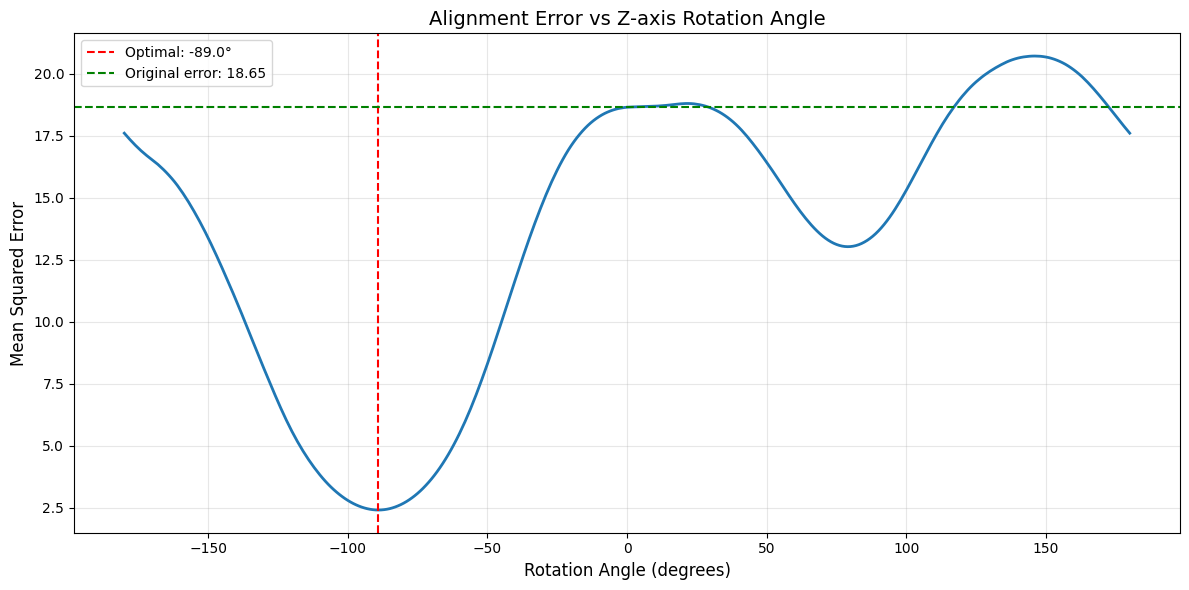


Visualizing OPTIMAL rotation (-89.0°) - Day 12 shifted +100mm in Y
Best Z-axis rotation to align Day 6 to Day 8: -89.0°
tobacco_shade_plant3: 3: -89.0


In [56]:
prev_idx = 4
curr_idx = 3 
prev_tp = problematic_seq['timepoints'][prev_idx]
curr_tp = problematic_seq['timepoints'][curr_idx]
organs_to_use = [0, 1, 2]  
best_angle, _ = get_best_z_rotation(prev_tp, curr_tp, organs_to_use=organs_to_use)
print(f"Best Z-axis rotation to align Day {curr_tp['day']} to Day {prev_tp['day']}: {best_angle:.1f}°")
print(f"{problematic_seq['sequence_name']}: {curr_idx}: {best_angle}")
# OK. Optimal yaw angle adjustment: -89.0°

In [54]:
plot_current_vs_rotated(prev_tp, curr_tp, 90)


Visualizing OPTIMAL rotation (90.0°) - Day 12 shifted +100mm in Y


Previous timepoint (Day 6): 10074 points
Current timepoint (Day 4): 7671 points

Original error: 9.011552

Optimal rotation angle: 150.0°
Optimal error: 6.438755
Original error: 9.011552
Improvement: 2.572797


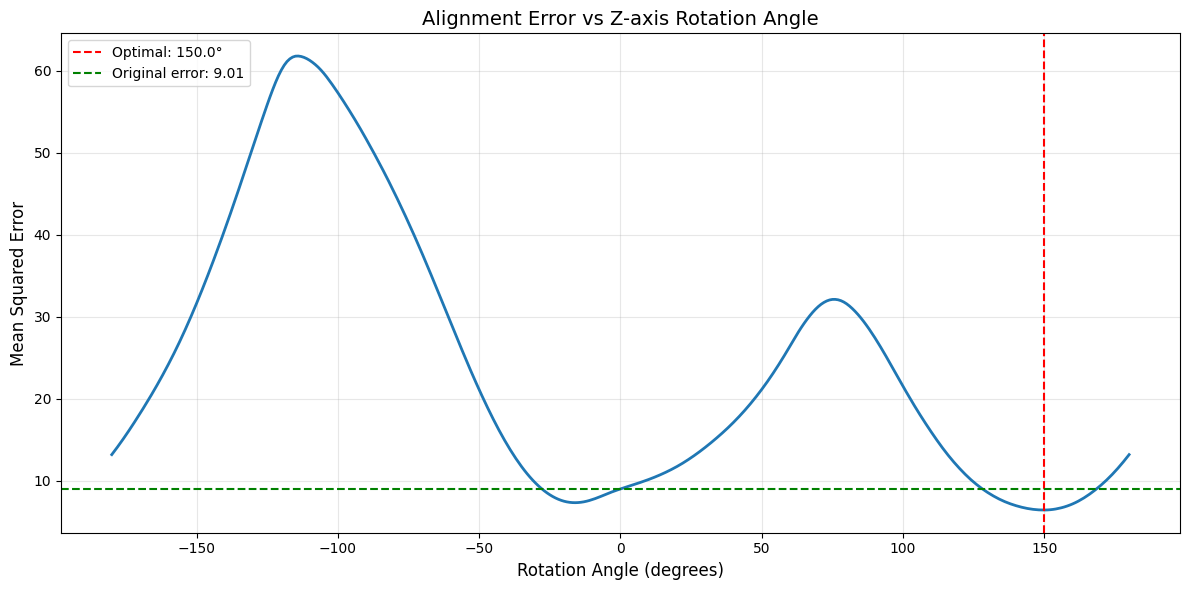


Visualizing OPTIMAL rotation (150.0°) - Day 12 shifted +100mm in Y
Best Z-axis rotation to align Day 4 to Day 6: 150.0°
tobacco_shade_plant3: 2: 150.0


In [55]:
prev_idx = 3
curr_idx = 2 
prev_tp = problematic_seq['timepoints'][prev_idx]
curr_tp = problematic_seq['timepoints'][curr_idx]
organs_to_use = [0, 1, 2, 3, 4, 5]  
best_angle, errors = get_best_z_rotation(prev_tp, curr_tp, organs_to_use=organs_to_use)
print(f"Best Z-axis rotation to align Day {curr_tp['day']} to Day {prev_tp['day']}: {best_angle:.1f}°")
print(f"{problematic_seq['sequence_name']}: {curr_idx}: {best_angle}")
# OK. Optimal yaw angle adjustment: 165° but need to correct error in organ labels in timestep 3!
# In this case the error was very low so it's clear it's a labeling issue due to symmetry, hierarchy (looking at future times
# it's clear that purple leaf comes out of blue leaf's peduncle)
# Why does 3 and 4 align so well then? timestep 4 also has wrong labels!

In [42]:
plot_current_vs_rotated(prev_tp, curr_tp, 165)


Visualizing OPTIMAL rotation (165.0°) - Day 12 shifted +100mm in Y


Previous timepoint (Day 4): 7671 points
Current timepoint (Day 2): 5970 points

Original error: 10.091831

Optimal rotation angle: -93.0°
Optimal error: 4.425859
Original error: 10.091831
Improvement: 5.665972


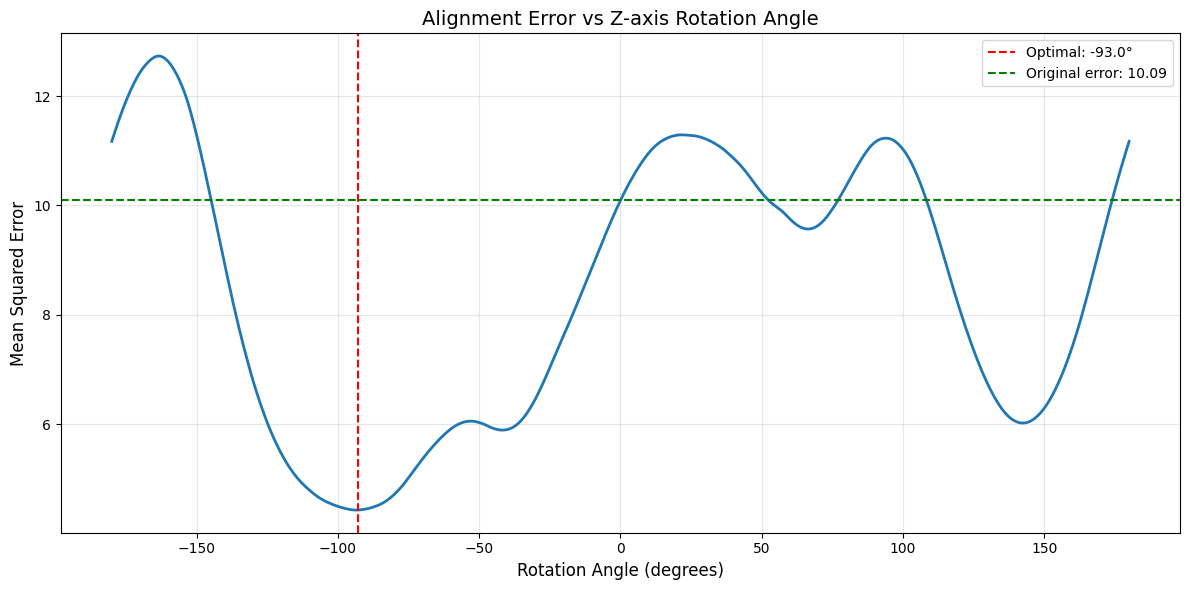


Visualizing OPTIMAL rotation (-93.0°) - Day 12 shifted +100mm in Y
Best Z-axis rotation to align Day 2 to Day 4: -93.0°
tobacco_shade_plant3: 1: -93.0


In [44]:
prev_idx = 2
curr_idx = 1 
prev_tp = problematic_seq['timepoints'][prev_idx]
curr_tp = problematic_seq['timepoints'][curr_idx]
organs_to_use = [0, 1, 2]  
best_angle, errors = get_best_z_rotation(prev_tp, curr_tp, organs_to_use=organs_to_use)
print(f"Best Z-axis rotation to align Day {curr_tp['day']} to Day {prev_tp['day']}: {best_angle:.1f}°")
print(f"{problematic_seq['sequence_name']}: {curr_idx}: {best_angle}")

In [32]:
plot_current_vs_rotated(prev_tp, curr_tp, 0)


Visualizing OPTIMAL rotation (0.0°) - Day 12 shifted +100mm in Y


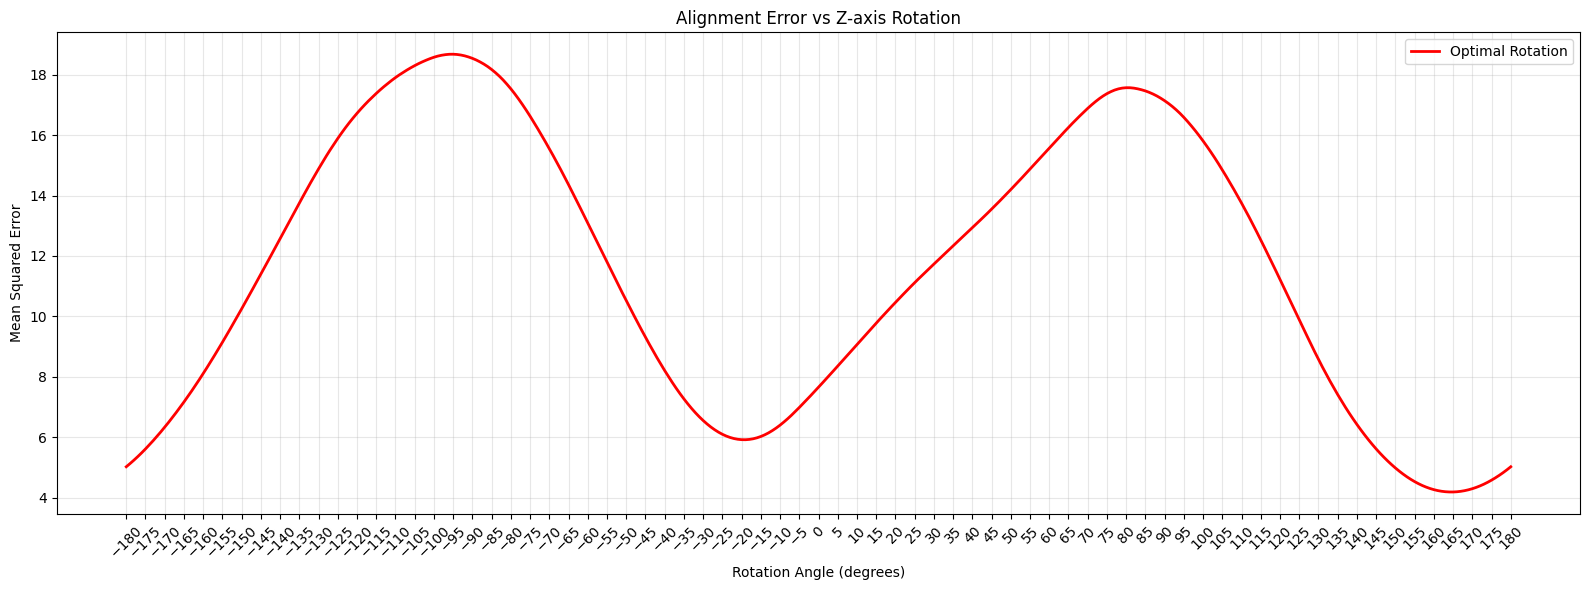

In [33]:
angles_deg = np.linspace(-180, 180, len(errors))  # match length of errors (361)
plt.figure(figsize=(16, 6))                       # make figure wider
plt.plot(angles_deg, errors, color='r', lw=2, label='Optimal Rotation')

# choose tick locations and show them rotated 45°
tick_locs = np.arange(-180, 181, 5)               # every 5 degrees
plt.xticks(tick_locs, rotation=45)

plt.xlabel('Rotation Angle (degrees)')
plt.ylabel('Mean Squared Error')
plt.title('Alignment Error vs Z-axis Rotation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Previous timepoint (Day 2): 5970 points
Current timepoint (Day 0): 7292 points

Original error: 13.515404

Optimal rotation angle: -37.0°
Optimal error: 11.785547
Original error: 13.515404
Improvement: 1.729857


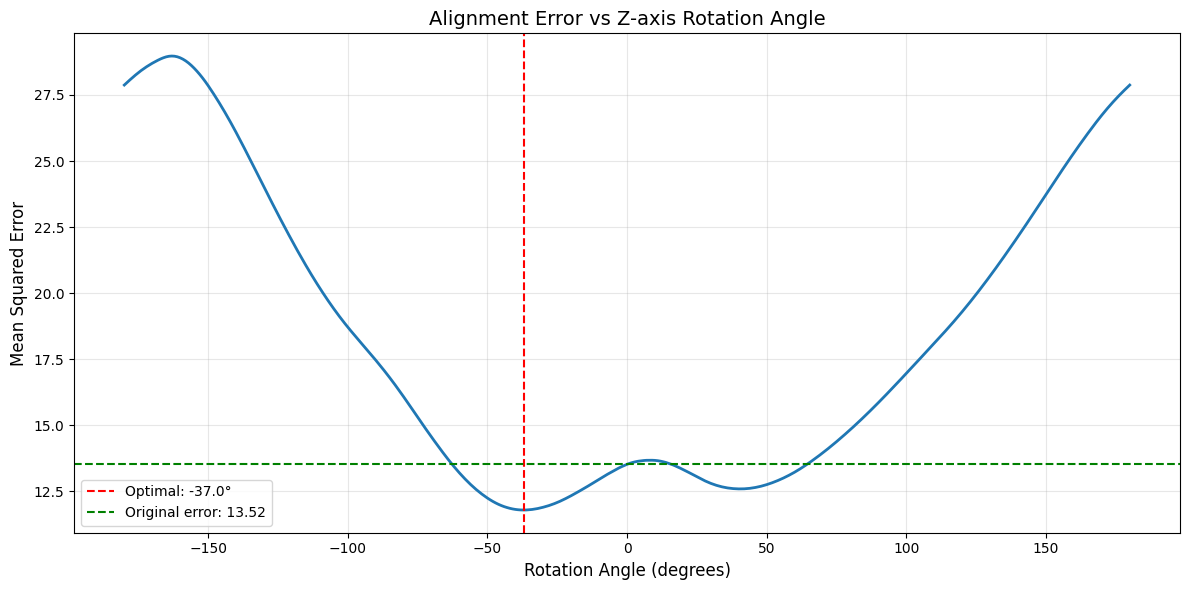


Visualizing OPTIMAL rotation (-37.0°) - Day 12 shifted +100mm in Y
Best Z-axis rotation to align Day 0 to Day 2: -37.0°
tobacco_shade_plant3: 0: -37.0


In [37]:
prev_idx = 1
curr_idx = 0 
prev_tp = problematic_seq['timepoints'][prev_idx]
curr_tp = problematic_seq['timepoints'][curr_idx]
organs_to_use = [0, 1]  
best_angle, errors = get_best_z_rotation(prev_tp, curr_tp, organs_to_use=organs_to_use)
print(f"Best Z-axis rotation to align Day {curr_tp['day']} to Day {prev_tp['day']}: {best_angle:.1f}°")
print(f"{problematic_seq['sequence_name']}: {curr_idx}: {best_angle}")
# Optimal yaw angle adjustment: -90 ° (pred: -37°, but it's not correct) 

In [36]:
plot_current_vs_rotated(prev_tp, curr_tp, -90) # eyeballing


Visualizing OPTIMAL rotation (-90.0°) - Day 12 shifted +100mm in Y


**#NOTE: Actually I discovered the wrong labels are from timestep 3 onwards. Need to swap 1 with 2, and 3 with 4 for these timepoints. Then check again if I actually need manual alignment!** See notebook 2 for correction.

#### Fix `sorghum_highlight_plant3` -> replaced by `sorghum_control_plant2`

### Apply manual changes

In [ ]:
dataset_path = Path("../data/TrackPlant3D/versions")
plant_dataset2 = PlantSequencesDataset(
    dataset_path,
    version="v1",
    alignment_method="stem_based",
    use_ply=True,
    manual_z_rotations={
        "tobacco_control_plant1": {6: -146.0},
        "tobacco_shade_plant3": {3: -89, 2: -89, 1: 165-89, 0: 165-89-90}, # applying -89 because previous timepoints were rotated by -89
        }
)

Applying STEM_BASED alignment to 43 plant sequences...
STEM_BASED alignment complete. 43 sequences aligned.


In [57]:
seq_name = "tobacco_control_plant1"
#seq_name = "tobacco_shade_plant3"
problematic_seq = plant_dataset2.get_timeseries_by_sequence_name(seq_name)
visualize_plant_sequence(problematic_seq, window_name=seq_name, spacing=100, normals_scale=0.2, show_normals=False, show_coordinate_frame=True, show_connections=True)

NameError: name 'plant_dataset2' is not defined